In [ ]:
!pip -q install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 29.3 MB/s eta 0:00:00


In [ ]:
!pip install optuna-integration[tfkeras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 8.0 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.upload()

Saving HAM_CLEAN_SPLIT.zip to HAM_CLEAN_SPLIT.zip


In [ ]:
!unzip -q "HAM_CLEAN_SPLIT.zip" -d /content/dataset

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

import optuna
from optuna.integration import TFKerasPruningCallback

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize


In [ ]:
CLEAN_ROOT = "/content/dataset/HAM_CLEAN_SPLIT"
TRAIN_DIR  = os.path.join(CLEAN_ROOT, "train")
VAL_DIR    = os.path.join(CLEAN_ROOT, "val")
TEST_DIR   = os.path.join(CLEAN_ROOT, "test")

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

Found 2984 files belonging to 7 classes.
Found 387 files belonging to 7 classes.
Found 390 files belonging to 7 classes.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [ ]:
mixed_precision.set_global_policy("mixed_float16")

AUTOTUNE = tf.data.AUTOTUNE
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess_batch(x, y):
    x = tf.cast(x, tf.float32)
    x = preprocess(x)
    return x, y

train_ds = train_ds.map(preprocess_batch, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess_batch,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess_batch,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

In [ ]:
def squeeze_excite_block(inputs, reduction=16):
    filters = inputs.shape[-1]  

   
    se = layers.GlobalAveragePooling2D()(inputs)
    se = layers.Reshape((1, 1, filters))(se)

   
    se = layers.Dense(filters // reduction,
                      activation="relu",
                      kernel_initializer="he_normal",
                      use_bias=False)(se)

    se = layers.Dense(filters,
                      activation="sigmoid",
                      kernel_initializer="he_normal",
                      use_bias=False)(se)

    
    x = layers.Multiply()([inputs, se])
    return x

In [ ]:
def build_se_model(dropout, se_reduction=16):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)

    
    x = squeeze_excite_block(x, reduction=se_reduction)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)
    model = keras.Model(inputs, outputs)
    return model

In [ ]:
def objective(trial):
    tf.keras.backend.clear_session()

    
    lr_head = trial.suggest_float("lr_head", 3e-5, 3e-3, log=True)
    lr_ft   = trial.suggest_float("lr_ft", 1e-6, 3e-4, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.6, step=0.05)
    unfreeze_last = trial.suggest_categorical("unfreeze_last", [20,30, 40, 50,60])
    weight_decay = trial.suggest_categorical("weight_decay", [0.0, 1e-5, 1e-4])
    label_smoothing = trial.suggest_categorical("label_smoothing", [0.0, 0.05, 0.1])

    model = build_se_model(dropout, se_reduction=16)

    loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)

    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_head, weight_decay=weight_decay),
        loss=loss_fn,
        metrics=["accuracy"]
    )

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=6,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True),
             TFKerasPruningCallback(trial, "val_accuracy")
            
        ],
        verbose=0
    )

    base_model = next(
        l for l in model.layers
        if isinstance(l, tf.keras.Model) and "mobilenetv2" in l.name.lower()
    )

    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_last]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_ft, weight_decay=weight_decay),
        loss=loss_fn,
        metrics=["accuracy"]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
            TFKerasPruningCallback(trial, "val_accuracy")
        ],
        verbose=0
    )

    return float(max(history.history["val_accuracy"]))


In [11]:
study_se = optuna.create_study(direction="maximize")
study_se.optimize(objective, n_trials=50)

print("SE Best Validation Accuracy:", study_se.best_value)
print("SE Best Hyperparameters:")
for k, v in study_se.best_params.items():
    print(k, ":", v)

[I 2026-02-27 09:52:34,559] A new study created in memory with name: no-name-5eb0e7c3-5123-40e4-98bc-e99da3946c35


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  self._trial.report(float(current_score), step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported value is ignored because this `step` 1 is already reported.
  self._trial.report(float(current_score), step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported value is ignored because this `step` 2 is already reported.
  self._trial.report(float(current_score), step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported value is ignored because this `step` 3 is already reported.
  self._trial.report(float(current_score), step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported 

SE Best Validation Accuracy: 0.7105942964553833
SE Best Hyperparameters:
lr_head : 0.0011993956998085607
lr_ft : 0.00014795442395216715
dropout : 0.25
unfreeze_last : 50
weight_decay : 0.0
label_smoothing : 0.05


In [ ]:
best_params = study_se.best_params
tf.keras.backend.clear_session()

final_model = build_se_model(best_params["dropout"], se_reduction=16)
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=best_params["label_smoothing"])

ckpt_path = "mobilenetv2_se_tuned_best.keras"


final_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=best_params["lr_head"],
        weight_decay=best_params["weight_decay"]
    ),
    loss=loss_fn,
    metrics=["accuracy"]
)

callbacks_fe = [
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
]

history_fe = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_fe,
    verbose=1
)


base_model = next(
    l for l in final_model.layers
    if isinstance(l, tf.keras.Model) and "mobilenetv2" in l.name.lower()
)

base_model.trainable = True
for layer in base_model.layers[:-best_params["unfreeze_last"]]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

final_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=best_params["lr_ft"],
        weight_decay=best_params["weight_decay"]
    ),
    loss=loss_fn,
    metrics=["accuracy"]
)

callbacks_ft = [
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
]

history_ft = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_ft,
    verbose=1
)


Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 194ms/step - accuracy: 0.4015 - loss: 1.6321 - val_accuracy: 0.5426 - val_loss: 1.3085 - learning_rate: 0.0012
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6825 - loss: 1.0131 - val_accuracy: 0.5943 - val_loss: 1.2384 - learning_rate: 0.0012
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7469 - loss: 0.8762 - val_accuracy: 0.6176 - val_loss: 1.2178 - learning_rate: 0.0012
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7942 - loss: 0.7711 - val_accuracy: 0.5943 - val_loss: 1.2295 - learning_rate: 0.0012
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8211 - loss: 0.7160 - val_accuracy: 0.6382 - val_loss: 1.2033 - learning_rate: 0.0012
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8400 - loss: 0.6578 - val_accuracy: 0.6382 - val_loss: 1.2242 - learning_rate: 0.0012
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8825 - loss: 0.5975 - val_a

In [ ]:

best_model = keras.models.load_model(ckpt_path)
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"\nSE Tuned Test Accuracy: {test_acc:.4f}")



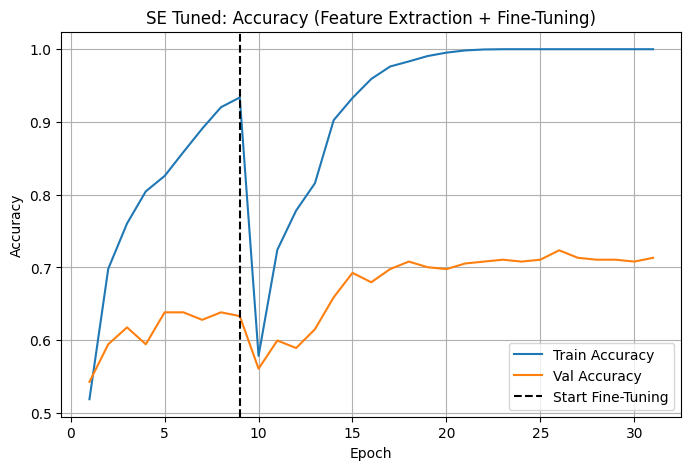

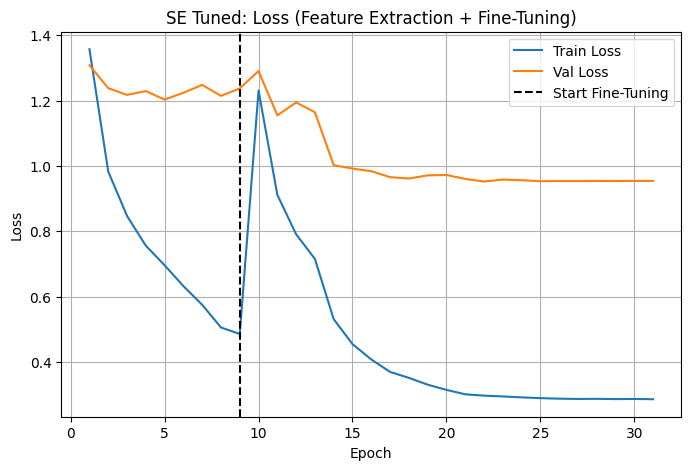

In [24]:
def combine_histories(h1, h2):
    combined = {}
    for key in ["accuracy", "val_accuracy", "loss", "val_loss"]:
        combined[key] = h1.history.get(key, []) + h2.history.get(key, [])
    return combined

combined = combine_histories(history_fe, history_ft)
epochs_total = range(1, len(combined["loss"]) + 1)
split_epoch = len(history_fe.history["loss"])

plt.figure(figsize=(8,5))
plt.plot(epochs_total, combined["accuracy"], label="Train Accuracy")
plt.plot(epochs_total, combined["val_accuracy"], label="Val Accuracy")
plt.axvline(split_epoch, linestyle="--", color="black", label="Start Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SE Tuned: Accuracy (Feature Extraction + Fine-Tuning)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs_total, combined["loss"], label="Train Loss")
plt.plot(epochs_total, combined["val_loss"], label="Val Loss")
plt.axvline(split_epoch, linestyle="--", color="black", label="Start Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SE Tuned: Loss (Feature Extraction + Fine-Tuning)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
y_true, y_pred = [], []
y_prob = []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    y_prob.extend(probs)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(probs, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - SE Tuned")
plt.show()

In [25]:
specificity = []
for i in range(len(cm)):
    tn = np.sum(cm) - (np.sum(cm[i,:]) + np.sum(cm[:,i]) - cm[i,i])
    fp = np.sum(cm[:,i]) - cm[i,i]
    specificity.append(tn / (tn + fp + 1e-8))

for cls, spec in zip(class_names, specificity):
    print(f"{cls} Specificity: {spec:.4f}")

akiec Specificity: 0.9559
bcc Specificity: 0.9302
bkl Specificity: 0.9365
df Specificity: 0.9892
mel Specificity: 0.9333
nv Specificity: 0.9397
vasc Specificity: 0.9946


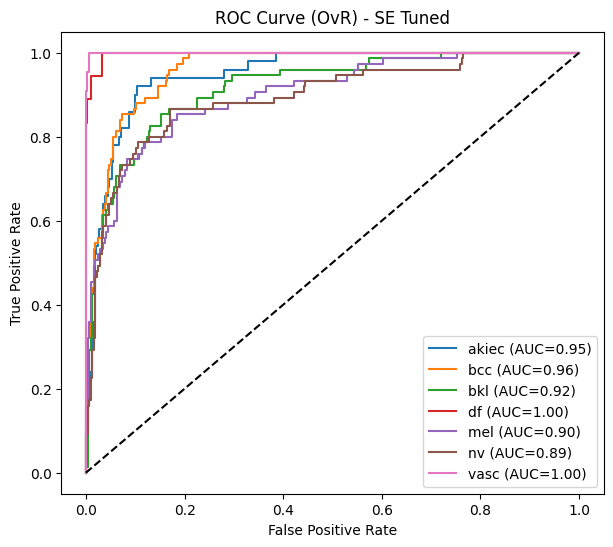

In [26]:
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

plt.figure(figsize=(7,6))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve (OvR) - SE Tuned")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


In [27]:
macro_auc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
print("Macro Average AUC:", macro_auc)


Macro Average AUC: 0.9454792207545605


In [28]:
import optuna.visualization as vis
vis.plot_param_importances(study_se)


In [ ]:
vis.plot_optimization_history(study_se)


In [29]:
vis.plot_parallel_coordinate(study_se)

In [33]:
best_model.save("mobilenetv2_se_besttuned.keras")


In [34]:
best_model.save_weights("mobilenetv2_se_besttuned.weights.h5")